In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
df = pd.read_csv("Cricket_dataset.csv")
print(df.columns)
print(df.shape)
print(df.head)

numeric_cols = ["runs_of_bat","wicket_type","wide","noballs"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols] = df[numeric_cols].fillna(0)

bowler_stats = df.groupby("bowler").agg({
    "runs_of_bat": "mean",
    "wicket_type": "mean",
    "wide": "mean",
    "noballs": "mean"
}).reset_index()

bowler_stats.columns = ["bowler","avg_runs","avg_wickets","avg_wides","avg_noballs"]

scaler = StandardScaler()
X_stats = scaler.fit_transform(bowler_stats.iloc[:,1:])



Index(['match_id', 'season', 'phase', 'match_no', 'date', 'venue',
       'batting_team', 'bowling_team', 'innings', 'over', 'striker', 'bowler',
       'runs_of_bat', 'extras', 'wide', 'legbyes', 'byes', 'noballs',
       'wicket_type', 'player_dismissed', 'fielder'],
      dtype='object')
(17246, 21)
<bound method NDFrame.head of        match_id  season        phase  match_no          date  \
0        202501    2025  Group Stage         1  Mar 22, 2025   
1        202501    2025  Group Stage         1  Mar 22, 2025   
2        202501    2025  Group Stage         1  Mar 22, 2025   
3        202501    2025  Group Stage         1  Mar 22, 2025   
4        202501    2025  Group Stage         1  Mar 22, 2025   
...         ...     ...          ...       ...           ...   
17241    202574    2025        Final        74  Jun 03, 2025   
17242    202574    2025        Final        74  Jun 03, 2025   
17243    202574    2025        Final        74  Jun 03, 2025   
17244    202574    2025   

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
bowler_stats["cluster"] = kmeans.fit_predict(X_stats)

print("\nKMeans Clusters Assigned:")
print(bowler_stats.head())


KMeans Clusters Assigned:
                bowler  avg_runs  avg_wickets  avg_wides  avg_noballs  cluster
0          Abdul Samad  3.000000          0.0   0.000000          0.0        1
1      Abhishek Sharma  1.656716          0.0   0.014925          0.0        0
2           Akash Deep  1.669291          0.0   0.102362          0.0        2
3        Akash Madhwal  1.631579          0.0   0.052632          0.0        0
4  Akash Maharaj Singh  1.477612          0.0   0.000000          0.0        0


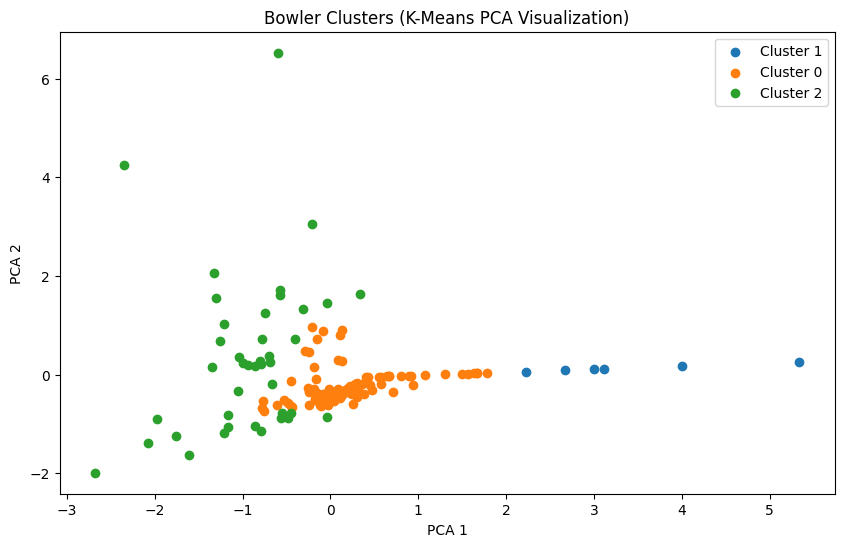

In [ ]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_stats)

bowler_stats["pca_x"] = pca_coords[:, 0]
bowler_stats["pca_y"] = pca_coords[:, 1]

plt.figure(figsize=(10, 6))
for c in bowler_stats["cluster"].unique():
    subset = bowler_stats[bowler_stats["cluster"] == c]
    plt.scatter(subset["pca_x"], subset["pca_y"], label=f"Cluster {c}")

plt.title("Bowler Clusters (K-Means PCA Visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()




Cluster mapping added to df:
      bowler  bowler_cluster
0  Hazlewood               0
1  Hazlewood               0
2  Hazlewood               0
3  Hazlewood               0
4  Hazlewood               0


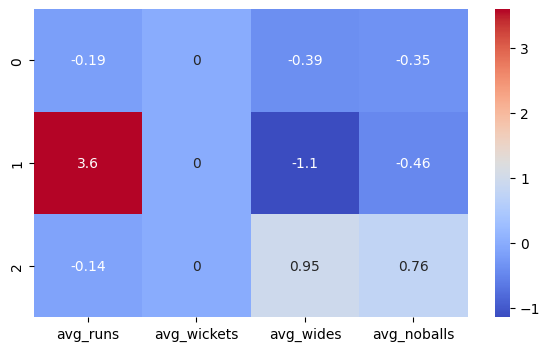

In [ ]:
plt.figure(figsize=(7, 4))
sns.heatmap(
    pd.DataFrame(
        kmeans.cluster_centers_,
        columns=["avg_runs", "avg_wickets", "avg_wides", "avg_noballs"]
    ),
    annot=True,
    cmap="coolwarm"
)
cluster_map = bowler_stats.set_index("bowler")["cluster"].to_dict()
df["bowler_cluster"] = df["bowler"].map(cluster_map)

print("\nCluster mapping added to df:")
print(df[["bowler", "bowler_cluster"]].head())

In [ ]:
bowler_econ = df.groupby("bowler")["runs_of_bat"].mean().to_dict()
df["bowler_mean_runs"] = df["bowler"].map(bowler_econ)

df["over_number"] = df["over"].astype(int)
df["ball"] = ((df["over"] % 1) * 10).astype(int)

X = df[[
    "runs_of_bat",
    "wide",
    "noballs",
    "wicket_type",
    "over_number",
    "ball",
    "bowler",
    "batting_team",
    "bowling_team",
    "venue"
]]

y = df["runs_of_bat"]
X = pd.get_dummies(X, drop_first=True)

RandomForestRegressor(max_features='sqrt', n_estimators=200, random_state=42)
GradientBoostingRegressor(n_estimators=150, random_state=42)


,RMSE,MAE,R2 Score
Random Forest,6.255149e-02,1.691493e-01,0.981223
Gradient Boosting,6.243046e-14,1.950558e-07,1.000000



 ***===Test Metrics Comparison===*** 



,RMSE,MAE,R2 Score
Random Forest,6.255149e-02,1.691493e-01,0.981223
Gradient Boosting,6.243046e-14,1.950558e-07,1.000000


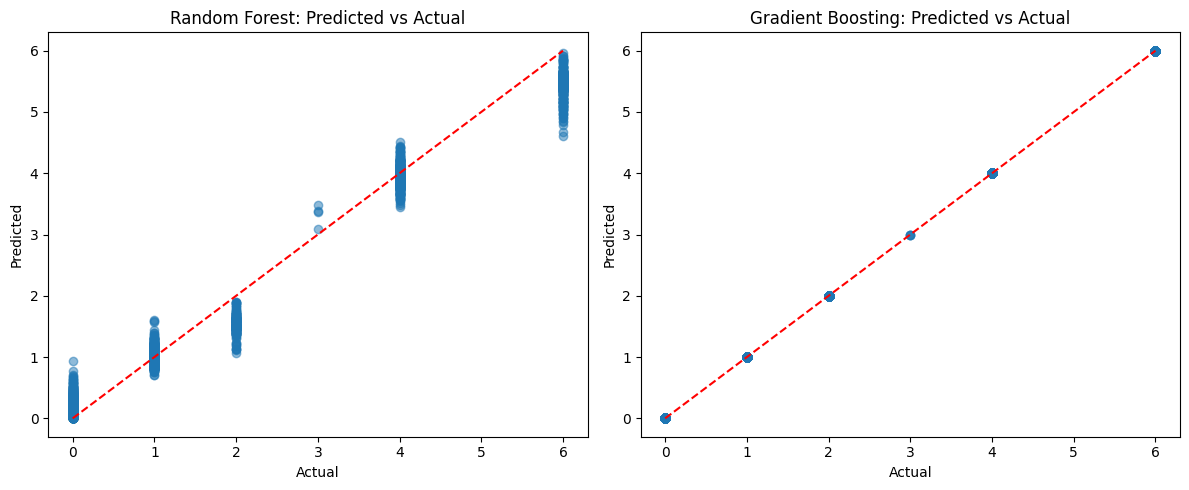

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(
    n_estimators=200,
    max_features='sqrt',
    random_state=42
)
print(rf)
rf.fit(X_train,y_train)

gb = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
print(gb)
gb.fit(X_train,y_train)

y_rf_pred = rf.predict(X_test)
y_gb_pred = gb.predict(X_test)

Metric_rf = {
    "RMSE": mean_squared_error(y_test, y_rf_pred),
    "MAE": mean_absolute_error(y_test, y_rf_pred),
    "R2 Score": r2_score(y_test, y_rf_pred)
}

Metric_gb = {
    "RMSE": mean_squared_error(y_test, y_gb_pred),
    "MAE": mean_absolute_error(y_test, y_gb_pred),
    "R2 Score": r2_score(y_test, y_gb_pred)
}

metrics_df = pd.DataFrame({
    "Random Forest": Metric_rf,
    "Gradient Boosting": Metric_gb
})

display(metrics_df.T)
print("\n ***===Test Metrics Comparison===*** \n")
display(metrics_df.T)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test, y_rf_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Predicted vs Actual")

plt.subplot(1,2,2)
plt.scatter(y_test, y_gb_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boosting: Predicted vs Actual")

plt.tight_layout()
plt.show()

In [ ]:
def recommend_bowler(batting_team, venue, upcoming_over):
    recommendations = []
    for bowler in df["bowler"].unique():
        row = pd.DataFrame([{
            "runs_of_bat": 0,
            "wide": 0,
            "noballs": 0,
            "wicket_type": 0,
            "over_number": int(upcoming_over),
            "ball": 0,
            "bowler": bowler,
            "batting_team": batting_team,
            "bowling_team": "UNKNOWN",
            "venue": venue
        }])
        row_encoded = pd.get_dummies(row)
        missing_cols = set(X.columns) - set(row_encoded.columns)
        if missing_cols:
            row_encoded = pd.concat(
                [row_encoded, pd.DataFrame(0, index=row_encoded.index, columns=list(missing_cols))],
                axis=1
            )
        row_encoded = row_encoded[X.columns]
        pred = rf.predict(row_encoded)[0]
        recommendations.append((bowler, pred))
    return sorted(recommendations, key=lambda x: x[1])[:5]
print("\nTop Bowlers Recommendation (Example):")
for bowler, p in recommend_bowler("MI", "Wankhede Stadium", 10):
    print(f"Bowler: {bowler}, Predicted Runs: {p:.2f}")


Top Bowlers Recommendation (Example):
Bowler: Suyash Sharma, Predicted Runs: 0.03
Bowler: Will Jacks, Predicted Runs: 0.03
Bowler: Kwena Maphaka, Predicted Runs: 0.03
Bowler: Vipraj Nigam, Predicted Runs: 0.04
Bowler: Abdul Samad, Predicted Runs: 0.04


In [ ]:
df = df.sort_values(["match_id","innings","over","ball"])
seq_features = ["runs_of_bat","wicket_type","wide","noballs",
                "byes","legbyes"]
minmax = MinMaxScaler()
df[seq_features] = minmax.fit_transform(df[seq_features])
SEQ_LEN = 6
X_seq, y_seq = [], []
for i in range(len(df) - SEQ_LEN):
    sequence = df[seq_features].iloc[i:i+SEQ_LEN].values
    target = df["runs_of_bat"].iloc[i + SEQ_LEN]
    X_seq.append(sequence)
    y_seq.append(target)
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)
lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, len(seq_features))),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(1)
])
lstm.compile(optimizer="adam", loss="mse")
lstm.summary()
lstm.fit(X_seq, y_seq, epochs=5, batch_size=64, validation_split=0.1)
print("\nLSTM Training Complete!")
def predict_next_ball(last6):
    """last6: DataFrame of last 6 deliveries with features."""
    scaled = minmax.transform(last6[seq_features])
    seq = np.expand_dims(scaled, axis=0)
    return lstm.predict(seq)[0][0]
example_last6 = df.tail(6)
print("\nNext Ball Predicted Runs:", predict_next_ball(example_last6))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 64)          │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0989 - val_loss: 0.0997
Epoch 2/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0887 - val_loss: 0.0989
Epoch 3/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0890 - val_loss: 0.0984
Epoch 4/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0908 - val_loss: 0.0987
Epoch 5/5
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0913 - val_loss: 0.1001

LSTM Training Complete!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step

Next Ball Predicted Runs: 0.19938594
